### Problem Statement
build a deep learning model that can distinguish between **real human voices** and **AI-generated voices (deepfakes)**.

### Goals
- Train a classifier to detect whether an audio clip is human or AI.
- Achieve strong performance metrics (Accuracy, F1-score).
- Provide clear documentation and visualizations

### Expected Outcomes
- A reproducible pipeline from raw audio → preprocessing → model training → evaluation.
- Visual outputs (spectrograms, confusion matrix).

In [15]:
import zipfile
import os

# Path to your downloaded zip file
zip_path = r"C:\Users\Ramandeep\Downloads\archive (2).zip"
extract_path = "voice_dataset"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

# Inspect folder structure
for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

Files extracted to: voice_dataset
voice_dataset -> 0 files
voice_dataset\DEMONSTRATION -> 0 files
voice_dataset\DEMONSTRATION\DEMONSTRATION -> 2 files
voice_dataset\KAGGLE -> 1 files
voice_dataset\KAGGLE\AUDIO -> 0 files
voice_dataset\KAGGLE\AUDIO\FAKE -> 56 files
voice_dataset\KAGGLE\AUDIO\REAL -> 8 files


In [16]:
import librosa, librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random

In [17]:
real_path = os.path.join(extract_path, "KAGGLE", "AUDIO", "REAL")
fake_path = os.path.join(extract_path, "KAGGLE", "AUDIO", "FAKE")

print("REAL path:", real_path)
print("FAKE path:", fake_path)

REAL path: voice_dataset\KAGGLE\AUDIO\REAL
FAKE path: voice_dataset\KAGGLE\AUDIO\FAKE


In [18]:
def preprocess_audio(file_path, sr=16000, n_mels=128, max_len=128, augment=False):
    y, sr = librosa.load(file_path, sr=sr)
    
    # Augmentation
    if augment:
        choice = random.choice(["noise", "pitch", "stretch"])
        if choice == "noise":
            y = y + 0.005 * np.random.randn(len(y))
        elif choice == "pitch":
            # ✅ FIX: pass sr as keyword argument
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.choice([-2, 2]))
        elif choice == "stretch":
            rate = random.choice([0.8, 1.2])
            y = librosa.effects.time_stretch(y, rate=rate)
    
    # Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Pad/Truncate
    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0,max_len-mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
    
    return mel_db

In [19]:
import glob

X, y = [], []

# Oversample REAL voices: generate 5 augmented versions per file
for f in glob.glob(os.path.join(real_path, "*.wav")):
    for _ in range(5):  # oversampling factor
        X.append(preprocess_audio(f, augment=True))
        y.append(0)

# FAKE voices (no oversampling)
for f in glob.glob(os.path.join(fake_path, "*.wav")):
    X.append(preprocess_audio(f))
    y.append(1)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)

Dataset shape: (96, 128, 128, 1) (96,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (76, 128, 128, 1) Val: (20, 128, 128, 1)


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Compute class weights to penalize misclassifying humans more
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print("Class weights:", class_weights_dict)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict
)

Class weights: {np.int64(0): np.float64(1.1875), np.int64(1): np.float64(0.8636363636363636)}
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 632ms/step - accuracy: 0.5395 - loss: 146.7150 - val_accuracy: 0.4000 - val_loss: 59.5161
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.4342 - loss: 45.9751 - val_accuracy: 0.6000 - val_loss: 4.6763
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 0.4474 - loss: 16.0592 - val_accuracy: 0.4000 - val_loss: 5.1817
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.5526 - loss: 3.7982 - val_accuracy: 0.6000 - val_loss: 1.4225
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.6316 - loss: 1.4201 - val_accuracy: 0.4000 - val_loss: 1.1584
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.6447 - loss: 1.0792 - val_accuracy: 0.6000 - val_loss: 0.6603
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.8158 - loss: 0.4824 - val_accuracy: 0.8500 - val_loss: 0.5927
Epoch 8/20
3/3 ━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


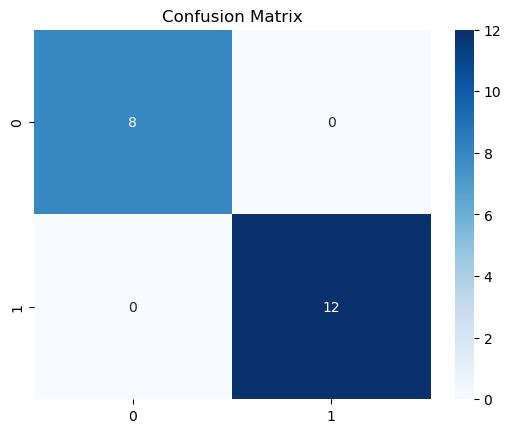

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_val) > 0.5).astype("int32")

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_val, y_pred))

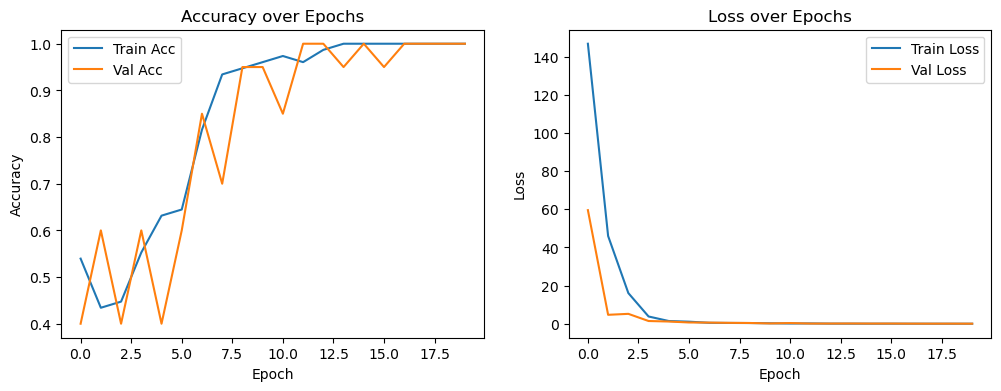

In [24]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [31]:
model.save("voice_model.keras")